In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [122]:
#index_col=['Order_Date']
data=pd.read_csv('cleaned_superStoreSales.csv')

In [123]:
data.dtypes

Unnamed: 0           int64
Row ID+O6G3A1:R6     int64
Order ID            object
Order Date          object
Ship Date           object
Ship Mode           object
Customer ID         object
Customer Name       object
Segment             object
Country             object
City                object
State               object
Region              object
Product ID          object
Category            object
Sub-Category        object
Product Name        object
Sales                int64
Quantity             int64
Profit               int64
Returns              int64
Payment Mode        object
dtype: object

**1. Data Preparation + Aggregation**

In [124]:
# Convert to datetime
data['Order Date'] = pd.to_datetime(data['Order Date'],format='mixed')

# Aggregate monthly (end-of-month)
monthly_data = (
    data
    .set_index('Order Date')
    .resample('ME')
    .agg({
        'Sales': 'sum',
        'Profit': 'sum'
    })
    .dropna()
)

print(monthly_data.head())
monthly_data_df=pd.DataFrame(monthly_data)
monthly_data_sales_df=monthly_data_df.drop(columns=['Profit'])
monthly_data_sales_df
monthly_data_sales_df.to_csv('monthly_data_sales_df.csv')


monthly_data_Profit_df=monthly_data_df.drop(columns=['Sales'])
monthly_data_Profit_df.to_csv('monthly_data_Profit_df.csv')

            Sales  Profit
Order Date               
2019-01-31  38031    8467
2019-02-28  25462   14636
2019-03-31  49502    1906
2019-04-30  45081    7354
2019-05-31  57812    9893


**2. ARIMA Forecasting**

**2A. Sales Forecast (ARIMA)**

In [125]:
from statsmodels.tsa.arima.model import ARIMA

# Fit model
sales_model = ARIMA(monthly_data['Sales'], order=(1,1,1))
sales_model_fit = sales_model.fit()

# Forecast 12 months
sales_forecast = sales_model_fit.forecast(steps=12)

# Create future index
sales_forecast_index = pd.date_range(
    start=monthly_data.index[-1],
    periods=13,
    freq='ME'
)[1:]

sales_forecast_df = pd.DataFrame({
    'Date': sales_forecast_index,
    'Sales_Forecast': sales_forecast.values
})

print(sales_forecast_df)

         Date  Sales_Forecast
0  2021-01-31   134475.998411
1  2021-02-28   126036.753346
2  2021-03-31   134450.323415
3  2021-04-30   126062.350230
4  2021-05-31   134424.804405
5  2021-06-30   126087.791602
6  2021-07-31   134399.440434
7  2021-08-31   126113.078408
8  2021-09-30   134374.230559
9  2021-10-31   126138.211586
10 2021-11-30   134349.173845
11 2021-12-31   126163.192069


**2B. Profit Forecast (ARIMA)**

In [126]:
# Fit model
profit_model = ARIMA(monthly_data['Profit'], order=(1,1,1))
profit_model_fit = profit_model.fit()

# Forecast
profit_forecast = profit_model_fit.forecast(steps=12)

# Index
profit_forecast_index = pd.date_range(
    start=monthly_data.index[-1],
    periods=13,
    freq='ME'
)[1:]

profit_forecast_df = pd.DataFrame({
    'Date': profit_forecast_index,
    'Profit_Forecast': profit_forecast.values
})

print(profit_forecast_df)

         Date  Profit_Forecast
0  2021-01-31      6909.021745
1  2021-02-28      7056.712963
2  2021-03-31      7001.347735
3  2021-04-30      7022.102581
4  2021-05-31      7014.322181
5  2021-06-30      7017.238831
6  2021-07-31      7016.145462
7  2021-08-31      7016.555335
8  2021-09-30      7016.401685
9  2021-10-31      7016.459284
10 2021-11-30      7016.437692
11 2021-12-31      7016.445786


**3. Prophet Forecasting**

**3A. Sales Forecast (Prophet)**

In [127]:
from prophet import Prophet

# Prepare data
sales_df = monthly_data.reset_index()[['Order Date', 'Sales']]
sales_df.columns = ['ds', 'y']

# Model
sales_prophet_model = Prophet(yearly_seasonality=True)
sales_prophet_model.fit(sales_df)

# Future
sales_future = sales_prophet_model.make_future_dataframe(periods=12, freq='ME')

# Forecast
sales_prophet_forecast = sales_prophet_model.predict(sales_future)

# Extract results
sales_prophet_result = sales_prophet_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

#print(sales_prophet_result.tail(12))

#sending the results to a dataframe
sales_prophet_df=pd.DataFrame(sales_prophet_result.tail(12))

new_names={'ds': 'Order Date','yhat': 'Sales','yhat_lower': 'lower_bound','yhat_upper':'upper_bound'}
sales_prophet_df=sales_prophet_df.rename(columns=new_names)
sales_prophet_df.head()

16:37:26 - cmdstanpy - INFO - Chain [1] start processing
16:37:26 - cmdstanpy - INFO - Chain [1] done processing


,Order Date,Sales,lower_bound,upper_bound
24,2021-01-31,82261.291091,80561.792671,83900.992619
25,2021-02-28,121912.521204,120148.956721,123593.371041
26,2021-03-31,142800.716639,140870.051707,144661.211224
27,2021-04-30,119329.852136,117164.919905,121677.438568
28,2021-05-31,133786.099044,131222.704197,136472.478076


In [128]:
sales_prophet_df=sales_prophet_df.drop(columns=['lower_bound','upper_bound'])
sales_prophet_df.set_index('Order Date',inplace=True)
sales_prophet_df.head()

,Sales
Order Date,
2021-01-31,82261.291091
2021-02-28,121912.521204
2021-03-31,142800.716639
2021-04-30,119329.852136
2021-05-31,133786.099044


In [129]:
sales_prophet_df.head()
sales_prophet_df.to_csv('sales_prophet_df.csv')

**3B. Profit Forecast (Prophet)**

In [130]:
# Prepare data
profit_df = monthly_data.reset_index()[['Order Date', 'Profit']]
profit_df.columns = ['ds', 'y']

# Model
profit_prophet_model = Prophet(yearly_seasonality=True)
profit_prophet_model.fit(profit_df)

# Future
profit_future = profit_prophet_model.make_future_dataframe(periods=12, freq='ME')

# Forecast
profit_prophet_forecast = profit_prophet_model.predict(profit_future)

# Extract
profit_prophet_result = profit_prophet_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

#print(profit_prophet_result.tail(12))

profit_prophet_df=pd.DataFrame(profit_prophet_result.tail(12))

new_names_profit={'ds': 'Order Date','yhat': 'Profit','yhat_lower': 'lower_bound','yhat_upper': 'upper_bound'}
profit_prophet_df=profit_prophet_df.rename(columns=new_names_profit)

16:37:27 - cmdstanpy - INFO - Chain [1] start processing
16:37:27 - cmdstanpy - INFO - Chain [1] done processing


In [131]:
profit_prophet_df=profit_prophet_df.drop(columns=['lower_bound','upper_bound'])

In [132]:

profit_prophet_df.set_index('Order Date',inplace=True)
profit_prophet_df.head()
profit_prophet_df.to_csv('profit_prophet_df.csv')

**4.  Visualization ARIMA Plot**

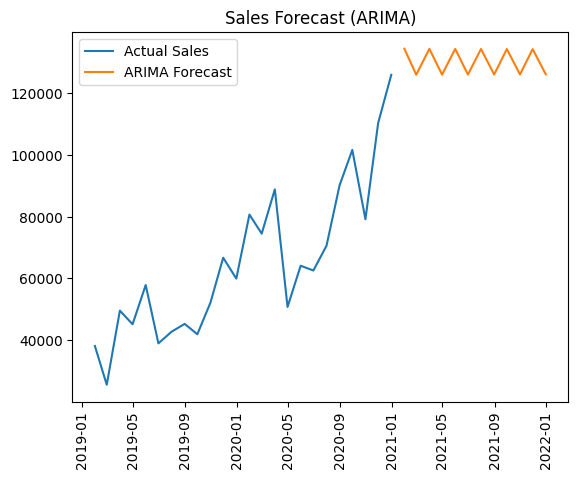

In [133]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(monthly_data.index, monthly_data['Sales'], label='Actual Sales')
plt.plot(sales_forecast_index, sales_forecast, label='ARIMA Forecast')
plt.legend()
plt.title("Sales Forecast (ARIMA)")
plt.xticks(rotation=90)
plt.show()

Prophet Plot

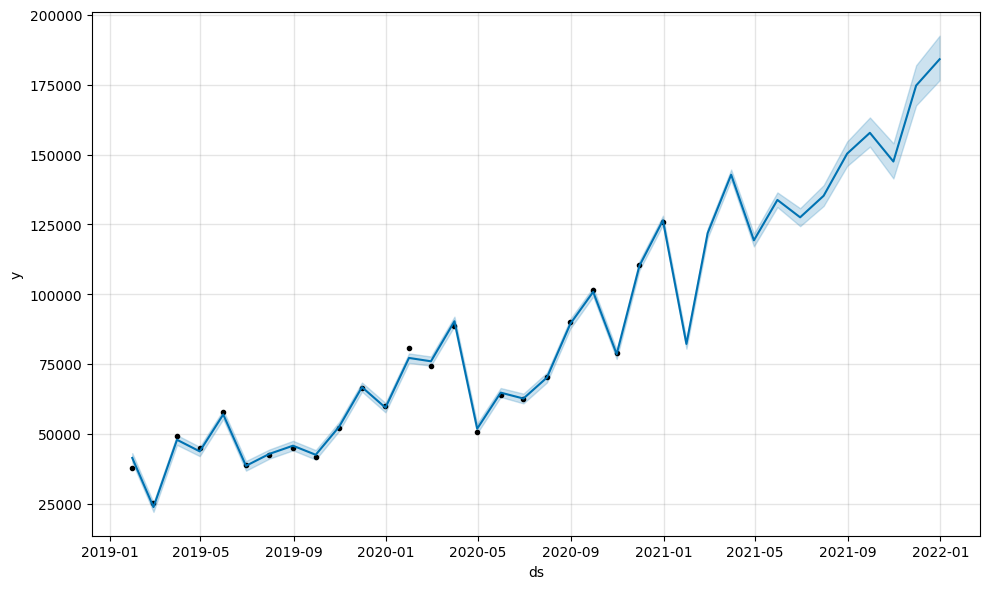

In [134]:
sales_prophet_model.plot(sales_prophet_forecast)
plt.show()

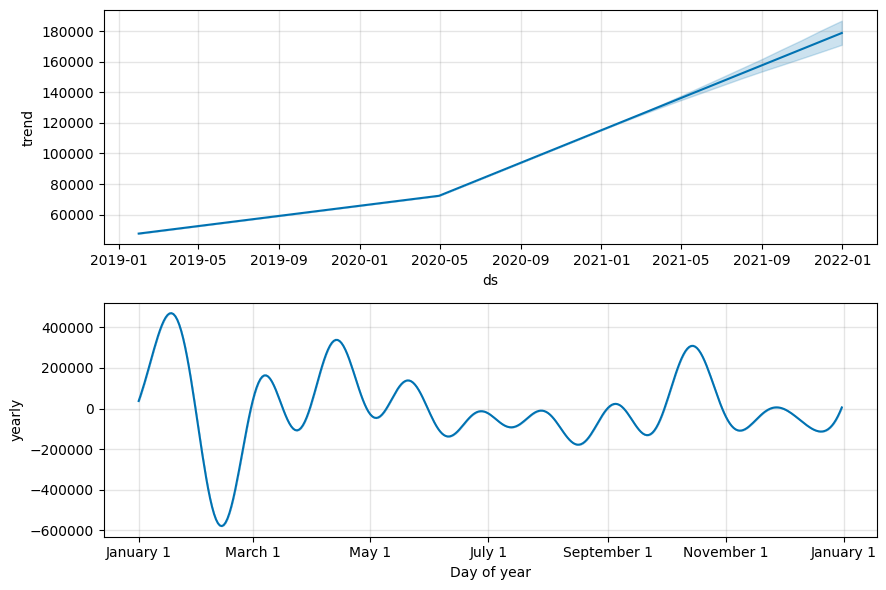

In [135]:
sales_prophet_model.plot_components(sales_prophet_forecast)
plt.show()

In [136]:
from pmdarima import auto_arima

auto_model = auto_arima(monthly_data['Sales'], seasonal=False)
print(auto_model.order)

(1, 1, 0)


"Prophet Forecasting wins..."